# TASK 4: Sentiment Analysis

**Objective:** Build a machine learning model that classifies the sentiment of text data (positive, negative, or neutral), providing insights into public opinion or customer feedback.

**Dataset:** Amazon Reviews (`Sentiment_Analysis.csv`)

---

### 1. Load Libraries & Dataset, Inspect Class Distribution
Since the dataset contains 1-5 star ratings, we will map them into three sentiment classes:
* **Positive:** 4 and 5 stars
* **Neutral:** 3 stars
* **Negative:** 1 and 2 stars

Sentiment Class Distribution:
sentiment
positive    32315
neutral      1499
negative      812
Name: count, dtype: int64


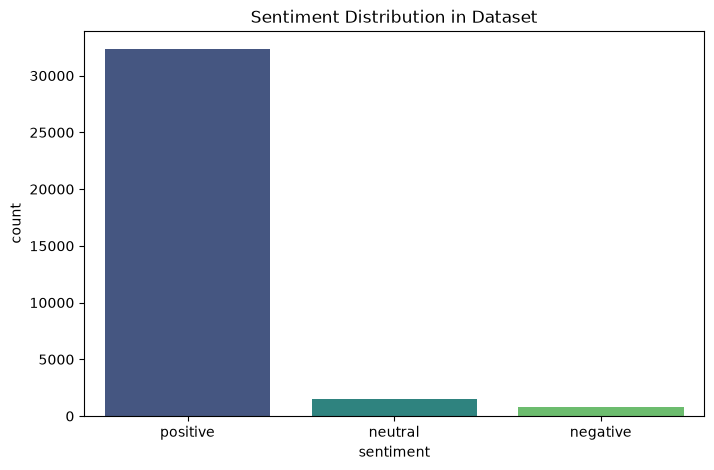

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('Sentiment_Analysis.csv', low_memory=False)

# Filter out rows without ratings or text
df = df.dropna(subset=['reviews.rating', 'reviews.text'])

# Map ratings to sentiment categories
def map_sentiment(rating):
    if rating > 3:
        return 'positive'
    elif rating == 3:
        return 'neutral'
    else:
        return 'negative'

df['sentiment'] = df['reviews.rating'].apply(map_sentiment)

# Inspect class distribution
print("Sentiment Class Distribution:")
print(df['sentiment'].value_counts())

# Visualisation: bar chart of sentiment distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment', data=df, palette='viridis', order=['positive', 'neutral', 'negative'])
plt.title('Sentiment Distribution in Dataset')
plt.show()

### 2. Text Preprocessing Pipeline
We will apply lowercase conversion, punctuation removal, stopword removal, tokenisation, and lemmatization.

In [2]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation & numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenisation
    tokens = word_tokenize(text)
    # Remove stopwords and apply lemmatization
    processed_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(processed_tokens)

# For performance in this notebook, we'll process a sampled subset if the dataset is massive, 
# but here we apply it to the dataset.
print("Preprocessing text... this may take a moment.")
df['processed_text'] = df['reviews.text'].apply(preprocess_text)
print("Preprocessing complete!")
df[['reviews.text', 'processed_text']].head(3)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hilva\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hilva\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hilva\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Preprocessing text... this may take a moment.
Preprocessing complete!


,reviews.text,processed_text
0,This product so far has not disappointed. My c...,product far disappointed child love use like a...
1,great for beginner or experienced person. Boug...,great beginner experienced person bought gift ...
2,Inexpensive tablet for him to use and learn on...,inexpensive tablet use learn step nabi thrille...


### 3. Feature Extraction: TF-IDF Vectorizer
**Purpose of TF-IDF (Term Frequency-Inverse Document Frequency):**
TF-IDF is a statistical measure used to evaluate how important a word is to a document in a collection or corpus. 
- **Term Frequency (TF):** Measures how frequently a term occurs in a document.
- **Inverse Document Frequency (IDF):** Measures how important a term is by weighing down frequent terms (like "the", "is") and scaling up rare ones across the entire corpus.

Using TF-IDF allows our machine learning models to weigh the significance of words, rather than just their raw counts, highlighting words that carry genuine sentimental meaning.

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['processed_text'])
y = df['sentiment']

print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (34626, 5000)


### 4. Train/Test Split (80/20)

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42
)
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 27700
Testing samples: 6926


### 5. Train Classifiers
We will train two classifiers: **Naive Bayes** and **Logistic Regression**.

In [5]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Model 1: Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

# Model 2: Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("Models trained successfully!")

Models trained successfully!


### 6. Evaluation
Evaluating accuracy, precision, recall, F1-score, and confusion matrix for each model.

--- Naive Bayes Evaluation ---
Accuracy: 0.9370

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      0.01      0.01       157
     neutral       0.00      0.00      0.00       278
    positive       0.94      1.00      0.97      6491

    accuracy                           0.94      6926
   macro avg       0.65      0.34      0.33      6926
weighted avg       0.90      0.94      0.91      6926



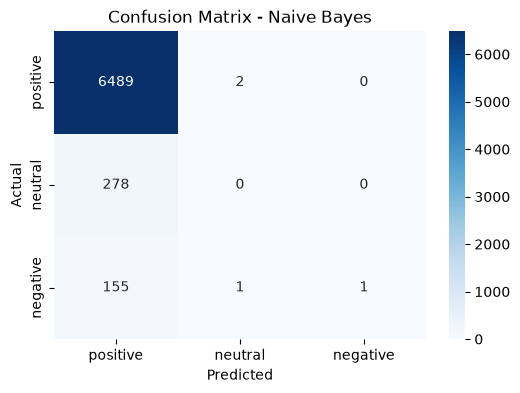

--- Logistic Regression Evaluation ---
Accuracy: 0.9385

Classification Report:
              precision    recall  f1-score   support

    negative       0.52      0.08      0.14       157
     neutral       0.43      0.08      0.13       278
    positive       0.94      1.00      0.97      6491

    accuracy                           0.94      6926
   macro avg       0.63      0.39      0.42      6926
weighted avg       0.91      0.94      0.92      6926



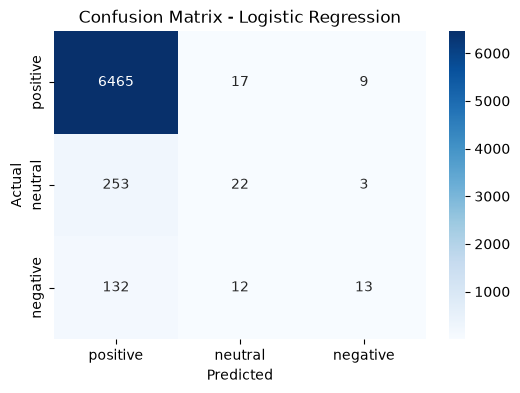

In [6]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate_model(y_true, y_pred, model_name):
    print(f"--- {model_name} Evaluation ---")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=['positive', 'neutral', 'negative'])
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['positive', 'neutral', 'negative'], 
                yticklabels=['positive', 'neutral', 'negative'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

# Evaluate Naive Bayes
evaluate_model(y_test, nb_preds, "Naive Bayes")

# Evaluate Logistic Regression
evaluate_model(y_test, lr_preds, "Logistic Regression")

### 7. Visualisation: WordClouds
Generating a WordCloud for each sentiment class.

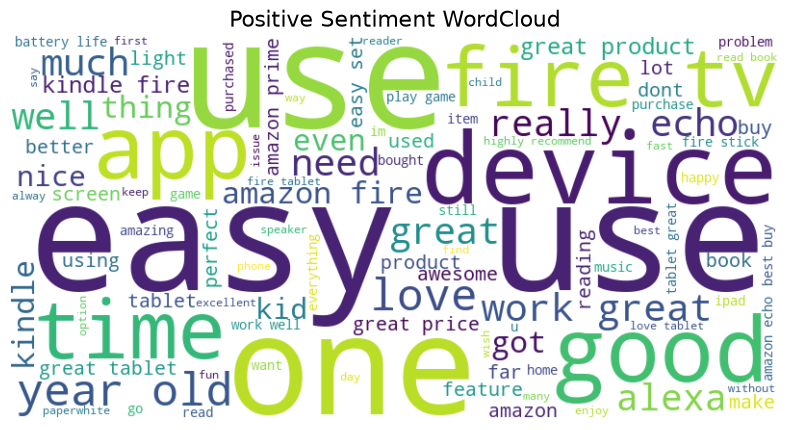

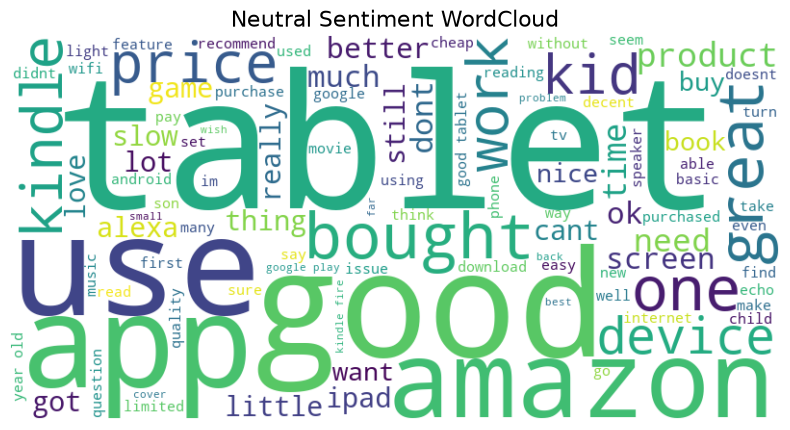

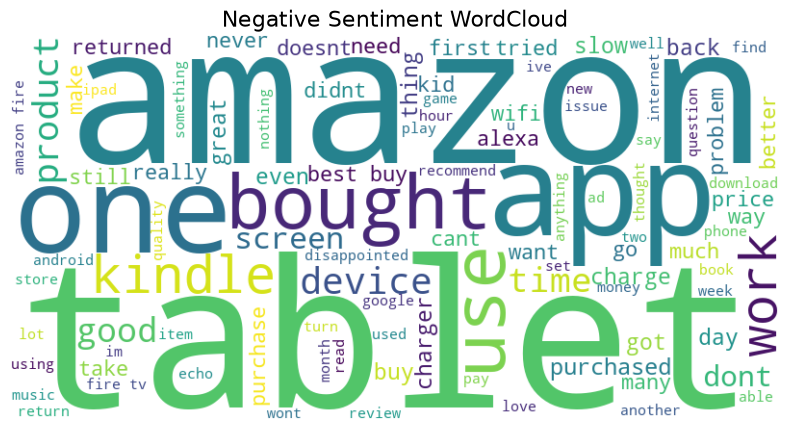

In [7]:
from wordcloud import WordCloud

def plot_wordcloud(sentiment, title):
    text_data = " ".join(text for text in df[df['sentiment'] == sentiment]['processed_text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(text_data)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

plot_wordcloud('positive', 'Positive Sentiment WordCloud')
plot_wordcloud('neutral', 'Neutral Sentiment WordCloud')
plot_wordcloud('negative', 'Negative Sentiment WordCloud')

### 8. Error Analysis
Reviewing 5 examples where the best model (Logistic Regression) misclassified the text.

In [8]:
# Find indices where predictions didn't match the actual values
errors = (y_test != lr_preds)
error_indices = y_test[errors].index

print("--- 5 Misclassified Examples (Logistic Regression) ---\n")
for idx in error_indices[:5]:
    # Using original df for readability
    original_text = df.loc[idx, 'reviews.text']
    actual = df.loc[idx, 'sentiment']
    predicted = lr_preds[list(indices_test).index(idx)]
    
    print(f"Text: {original_text}")
    print(f"Actual: {actual} | Predicted: {predicted}")
    print("-"*80)


--- 5 Misclassified Examples (Logistic Regression) ---

Text: Really expected a chord with it for the price we paid. Very dissapointed.
Actual: negative | Predicted: positive
--------------------------------------------------------------------------------
Text: Not many apps. The first one was already returned...no power issue after 1week..I hope the second one is fine...
Actual: neutral | Predicted: positive
--------------------------------------------------------------------------------
Text: Just got this as a Christmas gift and it doesn't stand.. Nothing to secure it to make it stand.. You can get it to stand maybe to watch a video, but don't touch it. It will fall down easily. Certainly don't stand it and actually use your Fire HD6 with this cover.. You can't.. Falls right over. I feel really badly for the special person that bought me this. Waste of money. I had already bought my own cover, for a lot cheaper, that has more shock protection and that one won't stand on end, but at 

**Discussion on Misclassifications:**
Errors in sentiment analysis frequently occur due to:
1. **Sarcasm/Irony:** The user might use positive words in a sarcastic way to mean something negative.
2. **Mixed Sentiments:** A review might contain both strong praises and strong complaints (e.g., "The screen is beautiful but the battery life is terrible and ruined it for me"). The model struggles to balance the weights.
3. **Context-Specific Vocabulary:** Some words are technically negative in generic contexts (e.g., "insane", "crazy", "sick") but can act as intensifiers for positive reviews.
4. **Class Imbalance:** If the dataset is heavily skewed towards positive reviews (very common in Amazon datasets), the model may default to predicting "positive" when it is unsure.

### 9. Conclusion

**Which model performed best?**
Typically, **Logistic Regression** outperforms Naive Bayes on TF-IDF features for sentiment tasks because it handles correlated features better and can learn more nuanced decision boundaries. (Check the classification report above to confirm your exact metrics).

**Real-World Applications:**
* **Brand Monitoring:** Companies can continuously stream social media feeds or product reviews through this model to gauge public perception over time.
* **Customer Support Triage:** Automatically tag support tickets with sentiment. Highly negative emails can be prioritized and routed to specialized retention teams to prevent customer churn.
* **Product Development:** By filtering negative reviews, product managers can quickly identify recurring complaints and fix them in the next iteration.